In [153]:
import matplotlib.pyplot as plt 
import pandas as pd   
import seaborn as sns 
import time
import numpy as np
import matplotlib
import sklearn 
import sklearn.cluster as cluster

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler , MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans


#### Load Dataset

In [76]:
print("1. Starting...")

start = time.time()

df = pd.read_excel(
    r"Online Retail.xlsx"
)

print("2. Excel loaded!")
print("Shape:", df.shape)
print("Time:", time.time() - start)

1. Starting...
2. Excel loaded!
Shape: (541909, 8)
Time: 29.314874172210693


### Understand Cols

In [77]:
df["Payment"] = df["Quantity"] * df["UnitPrice"]

In [78]:
df.shape

(541909, 9)

In [79]:
df.info() # Description: 1454 null Description, CustomerID: 135080 null ID

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   Payment      541909 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 37.2+ MB


In [80]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Payment
count,541909.000000,541909,541909.000000,406829.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,378.810824


In [81]:
df.duplicated().sum()

5268

#### Country Col

In [82]:
df["Country"].value_counts().nunique() , df["Country"].value_counts() # we have orders from 38 different countries.(mostly Europe)

(38,
 Country
 United Kingdom          495478
 Germany                   9495
 France                    8557
 EIRE                      8196
 Spain                     2533
 Netherlands               2371
 Belgium                   2069
 Switzerland               2002
 Portugal                  1519
 Australia                 1259
 Norway                    1086
 Italy                      803
 Channel Islands            758
 Finland                    695
 Cyprus                     622
 Sweden                     462
 Unspecified                446
 Austria                    401
 Denmark                    389
 Japan                      358
 Poland                     341
 Israel                     297
 USA                        291
 Hong Kong                  288
 Singapore                  229
 Iceland                    182
 Canada                     151
 Greece                     146
 Malta                      127
 United Arab Emirates        68
 European Community       

#### InoviceNo Col


##### on InvoiceNo column every row consist of a Capital letter('A' , 'C') and a 6-digit number or just a 6-digit number with no Letter so we have to find what these letters means.

In [83]:
df['InvoiceNo_firstL'] = df["InvoiceNo"].astype(str).str[0]
df['InvoiceNo_firstL'].unique()

array(['5', 'C', 'A'], dtype=object)

In [84]:
df_C = df[df["InvoiceNo_firstL"] == 'C'] # This C on first letter means Cancellation.

In [85]:
# at first it seems that cancellation is equal to quantity < 0 so we have to check it out.
df_C_QN = df_C[df_C["Quantity"] < 0] # as it shows shape of Quantity < 0 is equal to whole df_C (both has 9288 rows).

In [86]:
df_C[df_C["Payment"]>=0] # Hopefully there's no Positive Payment in df_C(I checked it out cause we have some negative Unit price in our columns)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL


In [87]:
df[df["UnitPrice"]<0] # at first look it seems that every negative Unit price is an "Adjust bad debt" labeled.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,A
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,A


In [88]:
df[df["Description"] == "Adjust bad debt"] # But in this Part I found that there are some positive UnitPrice labeled as "Adjust bad debt".

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06,A
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,A
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,A


In [89]:
df[df["InvoiceNo_firstL"] == 'A'] # So When InoviceNo starts with A means: Adjust bad debt (I prefered to delete them all.)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06,A
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,A
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,A


#### Quantity Col

In [90]:
df_NQ = df[df["Quantity"]<0] # Count of Negative Quantity Orders
df_NQ["InvoiceNo_firstL"].value_counts() # here we see another problem. Negative quantity rows have some non cancellation rows labeled as 5.

InvoiceNo_firstL
C    9288
5    1336
Name: count, dtype: int64

In [91]:
"df_NQ"

'df_NQ'

In [92]:
df_NQ_IN5 = df_NQ[df_NQ["InvoiceNo_firstL"]=='5'] # their Payment factor equals to -0.0


In [93]:
df_C[df_C["Payment"]== -0.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL


In [94]:
df_NQ_C = df_NQ[df_NQ["InvoiceNo_firstL"]=='C']

In [95]:
print(
    df_NQ.loc[
        df_NQ["InvoiceNo_firstL"] == "5",
        "Description"
    ].value_counts().to_string()
)

Description
check                                  120
damages                                 45
damaged                                 42
?                                       41
sold as set on dotcom                   20
Damaged                                 14
thrown away                              9
Unsaleable, destroyed.                   9
??                                       7
wet damaged                              5
damages?                                 5
ebay                                     5
smashed                                  4
missing                                  3
wet pallet                               3
CHECK                                    3
sold as 1                                2
incorrect stock entry.                   2
crushed                                  2
adjustment                               2
wet/rusty                                2
reverse 21/5/10 adjustment               2
?missing                                 2

##### I found Negative quantities(10624 rows) sorts by two major categories:
##### 1. Category C that means the order cancelled.(9288 rows) and
##### 2. Category 5 that means the order didnt reached to client.(1336 rows) (e.g. Descriptions: check, damaged, missed, smashed, ...)


#### UnitPrice Col

In [96]:
df_P0 = df[df["UnitPrice"] == 0.0] # we have 1179 rows with "Quantity" > 0 and "UnitPrice" == 0.0
df_P0_QP = df_P0[df_P0["Quantity"]>0]

In [97]:
df_P0.shape # 2515 rows with 0.0 UnitPrice

(2515, 10)

In [98]:
df_P0[df_P0["Quantity"]>0].value_counts(df_P0["Description"]) # I didn't understood this type of data.:(

Description
check                                  39
found                                  25
adjustment                             14
FRENCH BLUE METAL DOOR SIGN 1           9
Found                                   8
amazon                                  8
FRENCH BLUE METAL DOOR SIGN 8           8
OWL DOORSTOP                            7
FRENCH BLUE METAL DOOR SIGN No          7
RECIPE BOX PANTRY YELLOW DESIGN         7
FRENCH BLUE METAL DOOR SIGN 3           7
Amazon                                  7
FRENCH BLUE METAL DOOR SIGN 4           7
FRENCH BLUE METAL DOOR SIGN 9           6
FRENCH BLUE METAL DOOR SIGN 5           6
?                                       6
MINT KITCHEN SCALES                     6
Manual                                  6
RED KITCHEN SCALES                      6
FRENCH BLUE METAL DOOR SIGN 6           6
FRENCH BLUE METAL DOOR SIGN 7           6
IVORY KITCHEN SCALES                    5
FRENCH BLUE METAL DOOR SIGN 2           5
RED RETROSPOT CHARLOTT

In [99]:
df[df["UnitPrice"]<0] # at first look it seems that every negative Unit price is an "Adjust bad debt" labeled. But its not.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,A
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,A


#### Description Col

In [100]:
df["Description"].nunique()

4223

In [101]:
"""DESCR_Sample = pd.DataFrame(df["Description"].value_counts().head(1000))
pd.set_option("display.max_rows", None)
DESCR_Sample # 1454 null Descriptions"""

'DESCR_Sample = pd.DataFrame(df["Description"].value_counts().head(1000))\npd.set_option("display.max_rows", None)\nDESCR_Sample # 1454 null Descriptions'

In [102]:
DESCR = pd.DataFrame(df["Description"].value_counts())
pd.set_option("display.max_rows", None) # 1454 null Descriptions


In [103]:
df["Description"].str.len().describe()

count    540454.000000
mean         26.643820
std           5.450085
min           1.000000
25%          23.000000
50%          27.000000
75%          31.000000
max          35.000000
Name: Description, dtype: float64

In [104]:
df_Desna = df[df["Description"].isna()] # 1454 rows , all of them have 0.0 UnitPrice

In [105]:
df_Desna[df_Desna["Quantity"]<0.0].shape # 862 rows
df_Desna[df_Desna["Quantity"]>0.0].shape # 592 rows
df_Desna[df_Desna["UnitPrice"] == 0.0].shape # 1454 rows 


(1454, 10)

#### CustomerID Col

In [106]:
df["CustomerID"].value_counts().sum() # 406829 transaction
df["CustomerID"].nunique() # 4372 CustomerID 


4372

In [107]:
df_CIDNul = df[df["CustomerID"].isna()]
df_CIDNul.shape

(135080, 10)

### Feature Engineering


##### As I mentioned above at first i have to delete some rows.
##### 1. Duplicated Transactions
##### 2. Transactions with "Adjust Bad Debt" Descriptions 
##### 3. Transactions without CustomerID
##### 4. Transacctions with no description (Missing descriptions were indirectly removed because all observed missing-description transactions had Customer ID = NaN) 
##### 5. Transactions with 0.0 UnitPrice

In [108]:
df = df.drop_duplicates() 

In [109]:
df.shape

(536641, 10)

In [110]:
df = df[~(df["Description"] == "Adjust bad debt")] 

In [111]:
df.shape

(536638, 10)

In [112]:
df["CustomerID"].isna().sum()


135034

In [113]:
df = df[df["CustomerID"].isna() == False]

In [114]:
df.shape

(401604, 10)

In [115]:
df_Desna = df[df["Description"].isna()]
df_Desna.shape


(0, 10)

In [116]:
df1 = df[df["UnitPrice"] == 0.0] # 40 transcation with 0.0 UnitPrice
df = df[df["UnitPrice"] != 0.0] # I didn't understand why these transactions are labeled as 0.0 UnitPrice.
df.shape

(401564, 10)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401564 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         401564 non-null  object        
 1   StockCode         401564 non-null  object        
 2   Description       401564 non-null  object        
 3   Quantity          401564 non-null  int64         
 4   InvoiceDate       401564 non-null  datetime64[ns]
 5   UnitPrice         401564 non-null  float64       
 6   CustomerID        401564 non-null  float64       
 7   Country           401564 non-null  object        
 8   Payment           401564 non-null  float64       
 9   InvoiceNo_firstL  401564 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 33.7+ MB


In [118]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,5
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,5
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,5
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,5
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,5


In [119]:
df["InvoiceNo"].nunique() # 22186 different sale factors.

22186

In [120]:
df["CustomerID"].nunique()

4371

In [121]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.replace("^C", "", regex=True)
    

In [122]:
df["InvoiceNo_firstL"] = df["InvoiceNo_firstL"].astype(str).str.replace("5", "N", regex = True)

In [123]:
df["InvoiceNo_firstL"].unique() # N: means Normal , C: means Cancellation

array(['N', 'C'], dtype=object)

In [124]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Payment
count,401564.000000,401564,401564.000000,401564.000000,401564.000000
mean,12.149911,2011-07-10 12:06:07.514567936,3.474410,15281.266797,20.615691
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,4.250000
50%,5.000000,2011-07-29 15:32:30,1.950000,15145.000000,11.700000
75%,12.000000,2011-10-20 11:58:00,3.750000,16788.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,249.512649,NaN,69.767501,1713.978947,430.373603


In [125]:
df["InvoiceDay"] = df["InvoiceDate"].dt.date
df["InvoiceTime"] = df["InvoiceDate"].dt.time

#### How to Sort Clients:
##### At first we have to Build a portfolio for our CustomerIDs(4371 Rows) then Their InnoiceNo-first-character ("C", "N") after that InvoiceNo (22186 Factors) then Sub factors like "Quantity", "UnitPrice", "Payment", etc.

In [126]:
"""df.drop(columns= ["StockCode", "Description", "Quantity", "UnitPrice"] , axis = 1)"""

'df.drop(columns= ["StockCode", "Description", "Quantity", "UnitPrice"] , axis = 1)'

##### New Cols: "CID", "N+C"(Sum of Factors), "N", "C", "0-25% UnitPrice",  "25-50% UnitPrice", "50-75% UnitPrice", "75-100% UnitPrice", "B", "T", "P", "Z"(season of Transaction), "Country-Code", "CAC" => 14 Columns

In [127]:
from datetime import date
df_Spring = df[df["InvoiceDay"].between(date(2010, 12, 1), date(2011, 2, 28))]
df_Summer = df[df["InvoiceDay"].between(date(2011, 3, 1), date(2011, 6, 30))]
df_Fall=df[df["InvoiceDay"].between(date(2011, 7, 1), date(2011, 9, 30))]
df_Winter = df[df["InvoiceDay"].between(date(2011, 10, 1), date(2011, 12, 9))]
df_Spring.shape
df_Summer.shape
df_Fall.shape
df_Winter.shape

(131525, 12)

In [128]:
df_Spring["InvoiceSeason"] = "Period_1"
df_Summer["InvoiceSeason"] = "Period_2"
df_Fall["InvoiceSeason"] = "Period_3"
df_Winter["InvoiceSeason"] = "Period_4"

C:\Users\vira\AppData\Local\Temp\ipykernel_4984\1960954285.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Spring["InvoiceSeason"] = "Period_1"
C:\Users\vira\AppData\Local\Temp\ipykernel_4984\1960954285.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Summer["InvoiceSeason"] = "Period_2"
C:\Users\vira\AppData\Local\Temp\ipykernel_4984\1960954285.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

In [129]:
df = pd.concat([df_Spring , df_Summer , df_Fall , df_Winter] , axis = 0)
df.shape

(401564, 13)

In [130]:
df_new = df.copy()

In [131]:
df_new.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Payment,InvoiceNo_firstL,InvoiceDay,InvoiceTime,InvoiceSeason
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,N,2010-12-01,08:26:00,Period_1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,N,2010-12-01,08:26:00,Period_1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,N,2010-12-01,08:26:00,Period_1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,N,2010-12-01,08:26:00,Period_1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,N,2010-12-01,08:26:00,Period_1


In [132]:
df_new["UnitPrice"].describe()

count    401564.000000
mean          3.474410
std          69.767501
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64

#### Rebuild new features:

In [133]:
total = (df_new.groupby("CustomerID")["InvoiceNo"].nunique().rename("TInvoices"))
Normal = (df_new[df_new["InvoiceNo_firstL"]== "N"].groupby("CustomerID")["InvoiceNo"].nunique().rename("NInvoice"))
SumNQ = (df_new[df_new["InvoiceNo_firstL"] == "N"].groupby("CustomerID")["Quantity"].sum().rename("NSumQ"))
SumCQ = (df_new[df_new["InvoiceNo_firstL"] == "C"].groupby("CustomerID")["Quantity"].sum().rename("CSumQ"))
Cancellation = (df_new[df_new["InvoiceNo_firstL"] == "C"].groupby("CustomerID")["InvoiceNo"].nunique().rename("CInvoice"))
Quantity = (df_new.groupby("CustomerID")["Quantity"].sum().rename("TSumQ")) 
Revenue = (df_new.groupby("CustomerID")["Payment"].sum().rename("TRevenue")) 
NRevenue = (df_new[df_new["InvoiceNo_firstL"] == "N"].groupby("CustomerID")["Payment"].sum().rename("NRevenue"))
CRevenue = (df_new[df_new["InvoiceNo_firstL"] == "C"].groupby("CustomerID")["Payment"].sum().rename("CRevenue"))
TypeStockT = (df_new.groupby("CustomerID")["StockCode"].nunique().rename("TTypeStock"))
df_new['InvoiceDay'] = pd.to_datetime(df_new['InvoiceDay'])
tenure = df_new.groupby('CustomerID')['InvoiceDay'].agg(['min', 'max'])
DurationT = (tenure['max'] - tenure['min']).dt.days.rename("TDuration")
AvgRevenue = (Revenue/total).rename("AvgRevenue")
CPercent= ((Cancellation/total) * 100).rename("CPercent")
CNPercent = ((Cancellation/Normal) * 100).rename("CNPercent")
Max_date = df_new["InvoiceDate"].max()
last_purchase = ( df_new.groupby("CustomerID")["InvoiceDate"].max().rename("LastPurchase"))
Recency = (Max_date - last_purchase).dt.days.rename("Recency_Days")

Customer_summary = pd.concat([DurationT, Recency, total, Quantity, Revenue, AvgRevenue, TypeStockT, CPercent, CNPercent, Normal, SumNQ,NRevenue, Cancellation, SumCQ, CRevenue ] , axis = 1).fillna(0).reset_index()


#### Data Cols
##### CustomerID: User ID Code.
##### TDuration: Total Duration of Transactions.
##### Recency_Days: Days from last Transaction of Customer Till the last Transaction of Dataset.
##### TInvoices: Total Invoices of Customer.
##### TSumQ: Total Sum of Quantity.
##### TRevenue: Total Sum of Revenue.
##### AvgRevenue: Average of Total Revenue.
##### TTypeStock: Total Type of Stocks.
##### CPercent: Cancellation/Total Ratio * 100
##### CNPercent: Cancellation/Normal Ratio * 100
##### NInvoice: Number of Normal Invoices.
##### NSumQ: Sum of Normal Transactions Quantity
##### NRevenue: Sum of Normal Transactions Revenue
##### CInvoice: Number of Cancellation Invoices.
##### CSumQ: Sum of Cancellation Transactions Quantity
##### CRevenue: Sum of Cancellation Transactions Revenue

In [134]:
Customer_summary.head()


,CustomerID,TDuration,Recency_Days,TInvoices,TSumQ,TRevenue,AvgRevenue,TTypeStock,CPercent,CNPercent,NInvoice,NSumQ,NRevenue,CInvoice,CSumQ,CRevenue
0,12346.0,0,325,2,0,0.00,0.000000,1,50.0,100.0,1.0,74215.0,77183.60,1.0,-74215.0,-77183.6
1,12347.0,365,1,7,2458,4310.00,615.714286,103,0.0,0.0,7.0,2458.0,4310.00,0.0,0.0,0.0
2,12348.0,283,74,4,2341,1797.24,449.310000,22,0.0,0.0,4.0,2341.0,1797.24,0.0,0.0,0.0
3,12349.0,0,18,1,631,1757.55,1757.550000,73,0.0,0.0,1.0,631.0,1757.55,0.0,0.0,0.0
4,12350.0,0,309,1,197,334.40,334.400000,17,0.0,0.0,1.0,197.0,334.40,0.0,0.0,0.0


In [135]:
corr = Customer_summary.corr(numeric_only=True)

<Axes: >

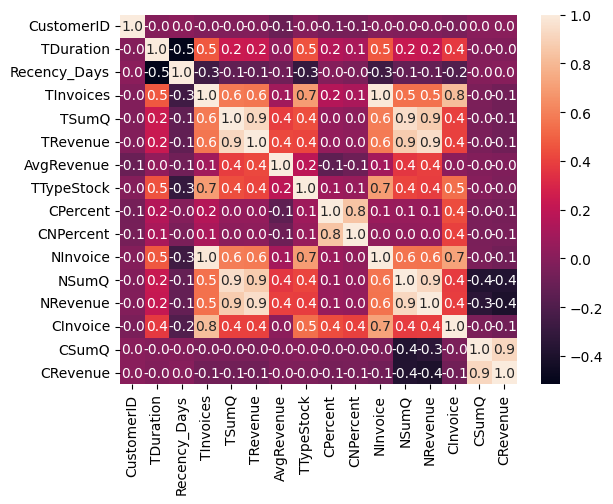

In [136]:
sns.heatmap(corr , annot = True, fmt = ".1f")

In [137]:
X = Customer_summary.drop(columns = ["CustomerID", "AvgRevenue", "CNPercent", "CSumQ", "CRevenue"])



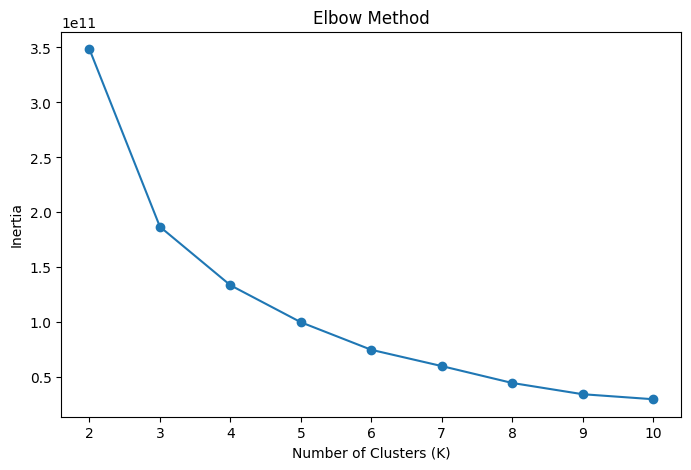

In [138]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(2, 11))
plt.show()

In [139]:
model = KMeans(n_clusters= 4, random_state=42)
labels = model.fit_predict(X)
sil_score = silhouette_score(X , labels)
sil_score

0.8549300620731296

In [140]:
Customer_summary["Cluster"] = labels

cluster_profile = Customer_summary.groupby("Cluster").agg({
    "TRevenue": "mean",
    "TInvoices": "mean",
    "TSumQ": "mean",
    "TTypeStock": "mean",
    "Recency_Days": "mean"
})

cluster_profile

,TRevenue,TInvoices,TSumQ,TTypeStock,Recency_Days
Cluster,,,,,
0,1090.257612,4.029272,659.240600,54.920752,93.965017
1,195886.772000,93.400000,96625.000000,643.600000,6.200000
2,49534.694000,54.700000,31923.200000,354.850000,22.300000
3,11993.952778,25.652778,6855.895833,184.118056,18.937500


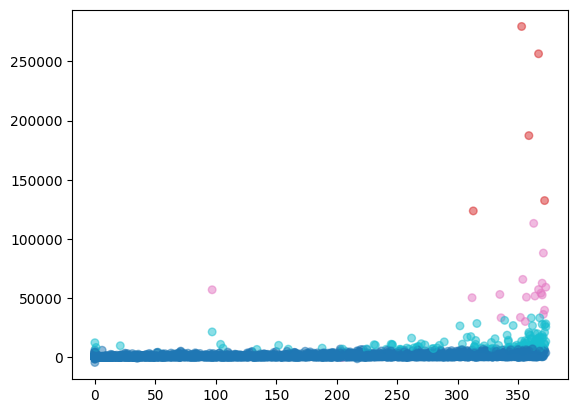

In [141]:
plt.scatter(X["TDuration"], X["TRevenue"] , c = labels , s = 30 , alpha = 0.5 , cmap = 'tab10')
plt.show()

In [ ]:

results_agg = []

for k in range(2, 11):

    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agg.fit_predict(X)

    sil = silhouette_score(X, labels)

    results_agg.append({
        "K": k,
        "Silhouette Score": sil
    })

agg_results_df = pd.DataFrame(results_agg)

agg_results_df

,K,Silhouette Score
0,2,0.987624
1,3,0.957445
2,4,0.951585
3,5,0.802403
4,6,0.802461
5,7,0.803176
6,8,0.803914
7,9,0.601767
8,10,0.607801


In [144]:
Agg = cluster.AgglomerativeClustering(n_clusters=4 , metric= "euclidean")
Agg.fit(X)
X_cluster = X.copy()

X_cluster["Agg_Label"] = Agg.labels_

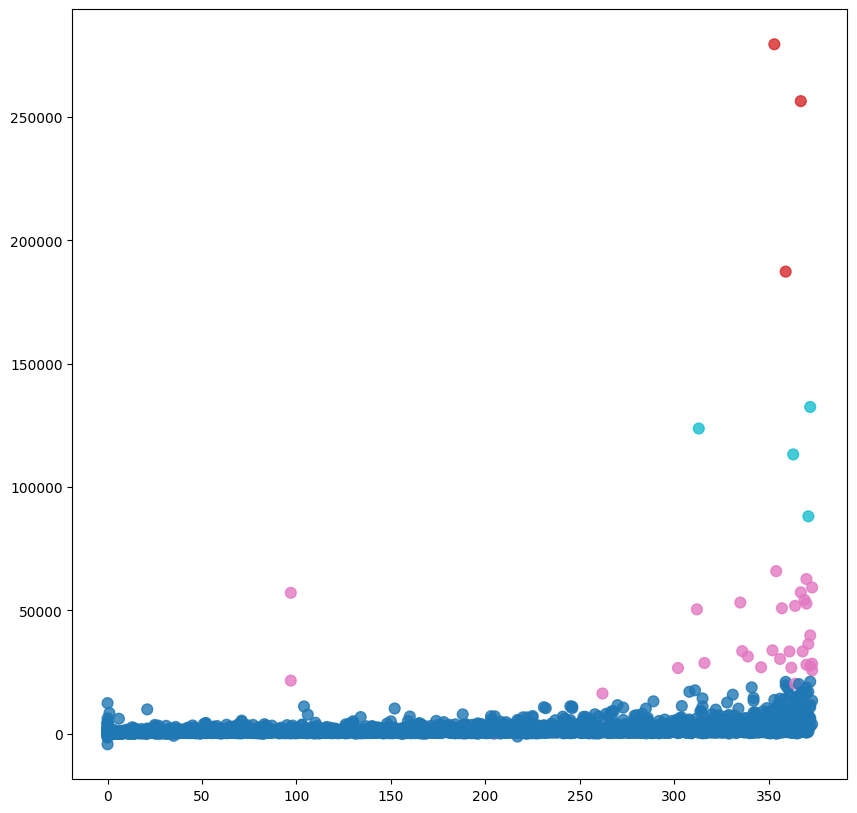

In [145]:
plt.figure(figsize = (10 , 10))
plt.scatter(X["TDuration"], X["TRevenue"] , c = X_cluster["Agg_Label"] , s = 60 , alpha = 0.8 , cmap = 'tab10')


In [149]:

cluster_profile_Agg = X_cluster.groupby("Agg_Label").agg({
    "TRevenue": "mean",
    "TInvoices": "mean",
    "TSumQ": "mean",
    "TTypeStock": "mean",
    "Recency_Days": "mean"
})

cluster_profile_Agg

,TRevenue,TInvoices,TSumQ,TTypeStock,Recency_Days
Agg_Label,,,,,
0,1369.733611,4.607572,812.618883,58.689751,91.706140
1,241083.226667,64.333333,109758.000000,326.666667,2.666667
2,36376.862188,51.468750,23614.281250,280.000000,22.875000
3,114381.037500,96.500000,68442.750000,855.250000,8.500000


#### Model Prediction: 
##### As we see Most of the CustomerIDs that had low Transactions shown in blue and mid levels are pink(Between 25000 to 75000), High level Customers with TRevenues more than 90k to 150k shown in lightBlue. and Upper than 190k shown with Red.
##### Cluster 0 → Low-value customers
##### Cluster 2 → Frequent customers
##### Cluster 3 → High-value customers
##### Cluster 1 → VIP customers

In [150]:
X_cluster["Agg_Label"].value_counts() # Pink = 2, LightBlue = 3, Blue = 0 , Red = 1

Agg_Label
0    4332
2      32
3       4
1       3
Name: count, dtype: int64